# **Simulação de Monte Carlo - Caso TechToy**
1. **Introdução e Contexto**

A empresa TechToy está prestes a lançar um novo drone no mercado. A diretoria está em dúvida entre duas estratégias de lançamento e contratou você, analista de dados, para realizar uma Simulação de Monte Carlo.

O objetivo é entender não apenas o lucro esperado, mas o risco de prejuízo de cada decisão.

As Estratégias:
Estratégia A (Conservadora): Foca em um público de nicho, com preço mais alto e vendas mais previsíveis.

Estratégia B (Agressiva): Foca em escala, com preço menor, mas com custos de produção e volume de vendas muito mais incertos.

2. **Base de Dados e Parâmetros**

Execute a célula abaixo para carregar as bibliotecas necessárias e os parâmetros oficiais fornecidos pelo departamento financeiro.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Configurações da Simulação
N_SIMULACOES = 10000

# --- PARÂMETROS ESTRATÉGIA A ---
vendas_media_a = 500
vendas_desvio_a = 50
custo_min_a = 600
custo_max_a = 700
preco_venda_a = 1200
investimento_fixo_a = 50000

# --- PARÂMETROS ESTRATÉGIA B ---
vendas_media_b = 800
vendas_desvio_b = 250
custo_min_b = 400
custo_max_b = 800
preco_venda_b = 1000
investimento_fixo_b = 150000

print("Parâmetros carregados com sucesso!")

Parâmetros carregados com sucesso!


3. **Desafio**

**1: Modelagem do Lucro**

Crie uma função ou um script que utilize os parâmetros acima para gerar 10.000 resultados possíveis de lucro para cada estratégia.
Dicas: Para as Vendas, use uma distribuição Normal: np.random.normal(media, desvio, N_SIMULACOES).
Para o Custo Unitário, use uma distribuição Uniforme: np.random.uniform(min, max, N_SIMULACOES).

A fórmula do lucro é:

$Lucro = (Vendas \times Preço) - (Vendas \times Custo\_Unitário) - Investimento\_Fixo$

In [25]:
def simular_lucro(vendas_media, vendas_desvio, custo_min, custo_max, preco_venda, investimento_fixo, n_simulacoes):
    # Gera vendas com distribuição normal
    vendas = np.random.normal(vendas_media, vendas_desvio, n_simulacoes)

    # Gera custo unitário com distribuição uniforme
    custo_unitario = np.random.uniform(custo_min, custo_max, n_simulacoes)

    # Calcula o lucro
    lucro = (vendas * preco_venda) - (vendas * custo_unitario) - investimento_fixo

    return lucro

# Gerando 10.000 resultados possíveis de lucro para cada estratégia
lucros_a = simular_lucro(vendas_media_a, vendas_desvio_a, custo_min_a, custo_max_a, preco_venda_a, investimento_fixo_a, N_SIMULACOES)
lucros_b = simular_lucro(vendas_media_b, vendas_desvio_b, custo_min_b, custo_max_b, preco_venda_b, investimento_fixo_b, N_SIMULACOES)

print("Primeiros 10 resultados de lucro - Estratégia A:")
print(lucros_a[:10])

print("\nPrimeiros 10 resultados de lucro - Estratégia B:")
print(lucros_b[:10])

Primeiros 10 resultados de lucro - Estratégia A:
[241461.93262825 237880.97228143 170479.31591869 199911.57460142
 203903.54749051 249775.73014984 250115.14860003 209875.79861493
 212080.23752949 227106.03351032]

Primeiros 10 resultados de lucro - Estratégia B:
[168849.88339759  31942.23659531 335229.01290439 199023.21450966
 348803.75695925 412363.64444053   2462.93386266 161047.39050795
 301504.10880189 -53253.20575519]


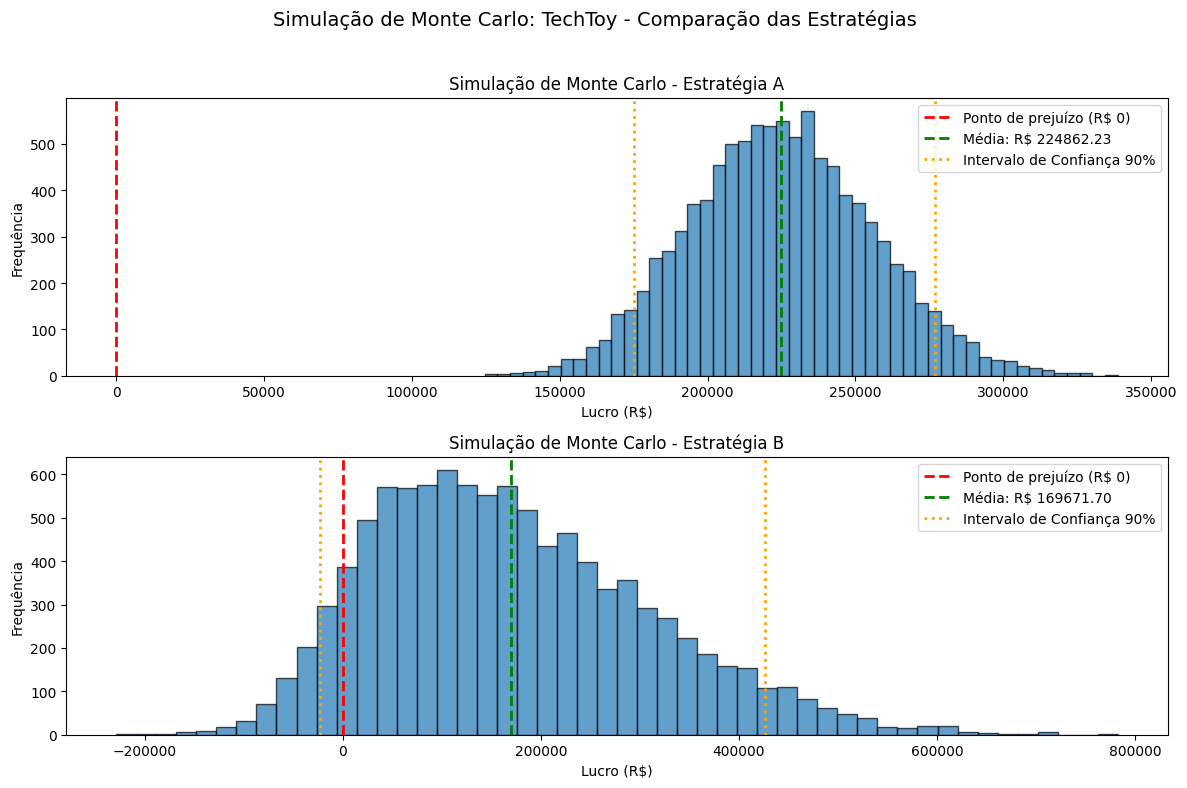

In [38]:
# 5. Visualização - Histogramas separados com intervalo de confiança
plt.figure(figsize=(12, 8))

# Cálculos da Estratégia A
media_a = lucros_a.mean()
p5_a = np.percentile(lucros_a, 5)
p95_a = np.percentile(lucros_a, 95)

# Cálculos da Estratégia B
media_b = lucros_b.mean()
p5_b = np.percentile(lucros_b, 5)
p95_b = np.percentile(lucros_b, 95)

# Histograma da Estratégia A
plt.subplot(2, 1, 1)
plt.hist(lucros_a, bins=50, alpha=0.7, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Ponto de prejuízo (R$ 0)')
plt.axvline(media_a, color='green', linestyle='--', linewidth=2, label=f'Média: R$ {media_a:.2f}')
plt.axvline(p5_a, color='orange', linestyle=':', linewidth=2, label='Intervalo de Confiança 90%')
plt.axvline(p95_a, color='orange', linestyle=':', linewidth=2)
plt.title('Simulação de Monte Carlo - Estratégia A')
plt.xlabel('Lucro (R$)')
plt.ylabel('Frequência')
plt.legend()

# Histograma da Estratégia B
plt.subplot(2, 1, 2)
plt.hist(lucros_b, bins=50, alpha=0.7, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Ponto de prejuízo (R$ 0)')
plt.axvline(media_b, color='green', linestyle='--', linewidth=2, label=f'Média: R$ {media_b:.2f}')
plt.axvline(p5_b, color='orange', linestyle=':', linewidth=2, label='Intervalo de Confiança 90%')
plt.axvline(p95_b, color='orange', linestyle=':', linewidth=2)
plt.title('Simulação de Monte Carlo - Estratégia B')
plt.xlabel('Lucro (R$)')
plt.ylabel('Frequência')
plt.legend()

plt.suptitle('Simulação de Monte Carlo: TechToy - Comparação das Estratégias', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

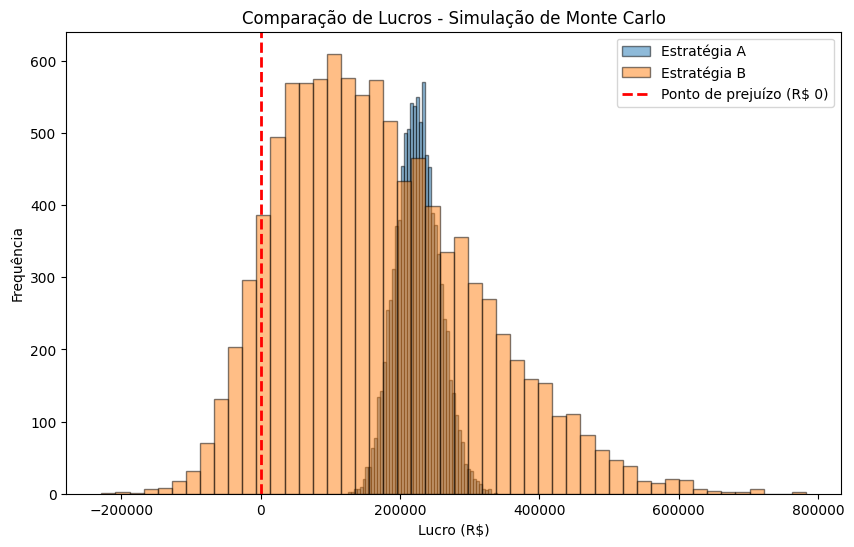

In [40]:
# 6. Visualização comparativa - histogramas sobrepostos
plt.figure(figsize=(10, 6))

plt.hist(lucros_a, bins=50, alpha=0.5, edgecolor='black', label='Estratégia A')
plt.hist(lucros_b, bins=50, alpha=0.5, edgecolor='black', label='Estratégia B')

plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Ponto de prejuízo (R$ 0)')

plt.title('Comparação de Lucros - Simulação de Monte Carlo')
plt.xlabel('Lucro (R$)')
plt.ylabel('Frequência')
plt.legend()

plt.show()

In [34]:
# Métricas da Estratégia A
media_lucro_a = np.mean(lucros_a)
prob_prejuizo_a = np.mean(lucros_a < 0) * 100

# Métricas da Estratégia B
media_lucro_b = np.mean(lucros_b)
prob_prejuizo_b = np.mean(lucros_b < 0) * 100

# Exibição dos resultados
print("Estratégia A")
print(f"Média de Lucro: R$ {media_lucro_a:.2f}")
print(f"Probabilidade de Prejuízo: {prob_prejuizo_a:.2f}%")

print("\nEstratégia B")
print(f"Média de Lucro: R$ {media_lucro_b:.2f}")
print(f"Probabilidade de Prejuízo: {prob_prejuizo_b:.2f}%")

Estratégia A
Média de Lucro: R$ 224862.23
Probabilidade de Prejuízo: 0.00%

Estratégia B
Média de Lucro: R$ 169671.70
Probabilidade de Prejuízo: 8.70%
